In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn -qb


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -b


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Country-data.csv to Country-data.csv


In [8]:
# Replace filename if different
df = pd.read_csv("Country-data.csv")

df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [9]:
df.columns = df.columns.str.strip()

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [16]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

In [17]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [18]:
countries = df['country']

X = df.drop('country', axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


In [19]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

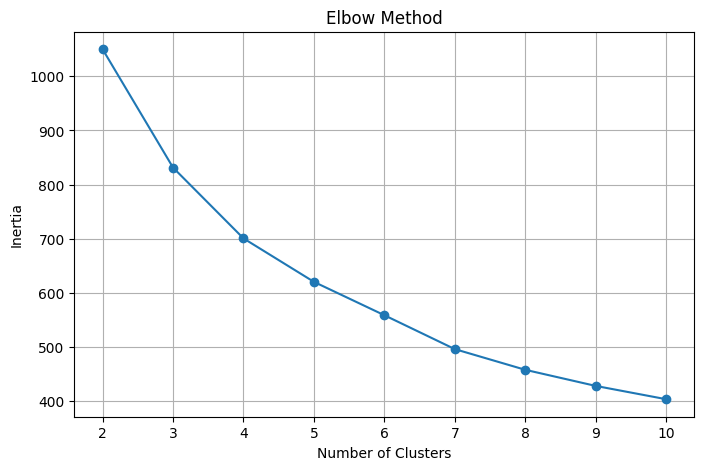

In [20]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [21]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print(df['KMeans_Cluster'].value_counts())

KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64


In [22]:
score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.28329575683463126


In [23]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


In [24]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

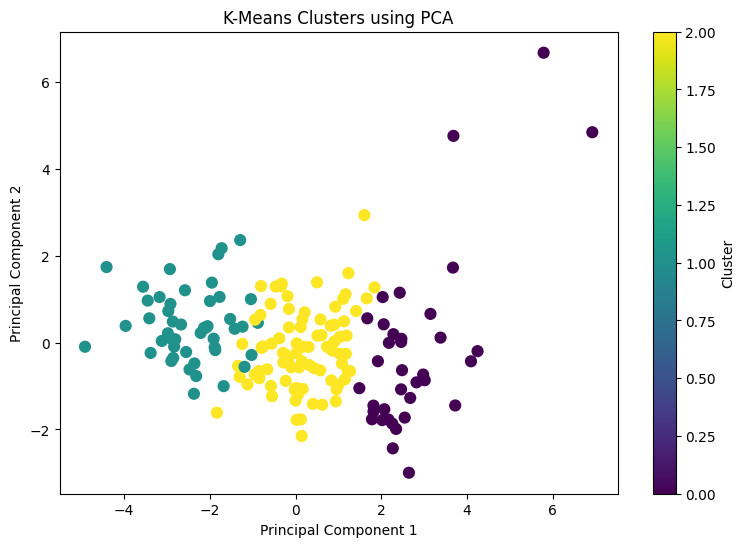

In [25]:
plt.figure(figsize=(9,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap='viridis',
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters using PCA")

plt.colorbar(scatter, label='Cluster')

plt.show()

Observation


Countries with high child mortality, low life expectancy, and low income formed a low-development cluster.
Economically strong countries with high GDP and income formed a high-development cluster.
Transitional economies appeared in the middle cluster with moderate indicators.
DBSCAN identified a few outlier countries with unusual socio-economic profiles.
PCA visualization showed a reasonable separation between the K-Means clusters.